# VGG16 + DenseNet121 Early Fusion — NTW Dataset — Participant-Level

This notebook trains and evaluates **both early-fusion methods**:

1. **Concatenation fusion**
2. **Attention fusion**

Each method is trained separately and saved in its own folder. Outputs include:

- `.keras` models
- Model summaries
- Parameter counts
- Training history CSV and JSON
- Accuracy, loss, and AUC graphs
- Accuracy, precision, recall, specificity, F1-score, and ROC-AUC
- Classification reports
- Confusion matrices
- ROC curves
- NPZ prediction files
- Prediction CSV files
- Clean fusion Grad-CAM examples
- Final concatenation-versus-attention comparison

## Final training schedule

- Concatenation fusion: **35 total epochs**
- Attention fusion: **35 total epochs**
- Stage 1 frozen-backbone training: **10 epochs**
- Stage 2 partial fine-tuning: **25 epochs**
- Total per fusion model: **35 epochs**
- Total after both fusion models finish: **70 model-training epochs**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:


import json
import random
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# CHANGE ONLY THESE THREE PATHS
ZIP_PATH = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/Parkinson_dataset_2.zip"
UNZIP_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Denesenet_patient_level_dataset_unzip_here"
SAVE_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

WARMUP_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
EPOCHS_PER_FUSION_MODEL = WARMUP_EPOCHS + FINE_TUNE_EPOCHS
TOTAL_EPOCHS_FOR_BOTH_FUSIONS = EPOCHS_PER_FUSION_MODEL * 2
VGG_FINE_TUNE_LAST = 8
DENSENET_FINE_TUNE_LAST = 30

FUSION_METHODS = ["concatenation", "attention"]

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
print("Results folder:", SAVE_DIR)
print("Frozen warm-up epochs:", WARMUP_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)
print("Epochs per fusion model:", EPOCHS_PER_FUSION_MODEL)
print("Total epochs for both fusion models:", TOTAL_EPOCHS_FOR_BOTH_FUSIONS)


Results folder: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here
Frozen warm-up epochs: 10
Fine-tuning epochs: 25
Epochs per fusion model: 35
Total epochs for both fusion models: 70


In [5]:
# UNZIP DATASET AND BUILD METADATA
if not Path(ZIP_PATH).exists():
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if Path(UNZIP_DIR).exists():
    try:
        shutil.rmtree(UNZIP_DIR)
    except FileNotFoundError as e:
        # This specific error indicates a sub-path was not found during recursive deletion.
        # This often means the directory was already partially cleared or is in an inconsistent state.
        # Since the next step is to recreate the directory and extract, we can usually
        # treat this as a non-fatal error and proceed.
        print(f"Warning: Encountered FileNotFoundError during rmtree for {UNZIP_DIR}. Error: {e}")
        print("This might indicate an inconsistent directory state, but the process will attempt to proceed.")
    except OSError as e:
        # Catch other potential OS errors (e.g., permission denied) which might be more critical.
        print(f"Error removing existing UNZIP_DIR {UNZIP_DIR}: {e}")
        raise # Re-raise other unexpected OS errors

Path(UNZIP_DIR).mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(UNZIP_DIR)

def find_dataset_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if (candidate / "healthy_control").is_dir() and (candidate / "parkinson").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find a folder containing both healthy_control and parkinson."
    )

DATASET_ROOT = find_dataset_root(UNZIP_DIR)
print("Dataset root:", DATASET_ROOT)

valid_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
class_mapping = {"healthy_control": 0, "parkinson": 1}

records = []

for class_name, label in class_mapping.items():
    for image_path in (DATASET_ROOT / class_name).rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in valid_extensions:
            records.append(
                {
                    "filepath": str(image_path),
                    "label": label,
                    "class_name": class_name,
                    "patient_id": image_path.parent.name,
                    "source_dataset": image_path.parent.parent.name,
                }
            )

df = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)

if df.empty:
    raise ValueError("No images were found.")

print("Total images:", len(df))
print("\nImages by class:")
print(df["class_name"].value_counts())

print("\nParticipants by class:")
print(df.groupby("class_name")["patient_id"].nunique())

print("\nImages by source dataset:")
print(df["source_dataset"].value_counts())

print("\nImages per participant:")
display(df.groupby("patient_id").size().describe().to_frame("images_per_participant"))

df.to_csv(Path(SAVE_DIR) / "NTW_complete_metadata.csv", index=False)

Dataset root: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Denesenet_patient_level_dataset_unzip_here/sagittal_images
Total images: 3320

Images by class:
class_name
parkinson          1880
healthy_control    1440
Name: count, dtype: int64

Participants by class:
class_name
healthy_control    36
parkinson          47
Name: patient_id, dtype: int64

Images by source dataset:
source_dataset
NEUROCON    1720
Tao_Wu      1600
Name: count, dtype: int64

Images per participant:


,images_per_participant
count,83.0
mean,40.0
std,0.0
min,40.0
25%,40.0
50%,40.0
75%,40.0
max,40.0


In [6]:
# PARTICIPANT-DISJOINT 70/15/15 SPLIT
participant_table = (
    df.groupby("patient_id", as_index=False)
    .agg(
        label=("label", "first"),
        class_name=("class_name", "first"),
        source_dataset=("source_dataset", "first"),
        number_of_images=("filepath", "size"),
    )
)

train_participants, temporary_participants = train_test_split(
    participant_table,
    test_size=0.30,
    random_state=SEED,
    stratify=participant_table["label"],
)

validation_participants, test_participants = train_test_split(
    temporary_participants,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_participants["label"],
)

train_ids = set(train_participants["patient_id"])
validation_ids = set(validation_participants["patient_id"])
test_ids = set(test_participants["patient_id"])

assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

train_df = df[df["patient_id"].isin(train_ids)].copy()
validation_df = df[df["patient_id"].isin(validation_ids)].copy()
test_df = df[df["patient_id"].isin(test_ids)].copy()

for split_name, participant_frame, image_frame in [
    ("Training", train_participants, train_df),
    ("Validation", validation_participants, validation_df),
    ("Testing", test_participants, test_df),
]:
    print(
        f"\n{split_name}: {len(participant_frame)} participants, "
        f"{len(image_frame)} images"
    )
    print(participant_frame["class_name"].value_counts())

train_participants.to_csv(
    Path(SAVE_DIR) / "participant_train_split.csv",
    index=False,
)
validation_participants.to_csv(
    Path(SAVE_DIR) / "participant_validation_split.csv",
    index=False,
)
test_participants.to_csv(
    Path(SAVE_DIR) / "participant_test_split.csv",
    index=False,
)


Training: 58 participants, 2320 images
class_name
parkinson          33
healthy_control    25
Name: count, dtype: int64

Validation: 12 participants, 480 images
class_name
parkinson          7
healthy_control    5
Name: count, dtype: int64

Testing: 13 participants, 520 images
class_name
parkinson          7
healthy_control    6
Name: count, dtype: int64


In [7]:
# DUAL-INPUT TF.DATA PIPELINE
AUTOTUNE = tf.data.AUTOTUNE

augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.04, fill_mode="nearest", seed=SEED),
        layers.RandomZoom(0.10, fill_mode="nearest", seed=SEED),
        layers.RandomTranslation(
            0.05,
            0.05,
            fill_mode="nearest",
            seed=SEED,
        ),
    ],
    name="augmentation",
)

def decode_dual_input(path, label, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    if training:
        image = augmentation(image, training=True)

    return {
        "vgg_input": vgg_preprocess(tf.identity(image)),
        "dense_input": dense_preprocess(tf.identity(image)),
    }, tf.cast(label, tf.float32)

def make_dataset(frame, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            frame["filepath"].astype(str).values,
            frame["label"].astype("float32").values,
        )
    )

    if training:
        dataset = dataset.shuffle(
            len(frame),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        lambda path, label: decode_dual_input(path, label, training),
        num_parallel_calls=AUTOTUNE,
    )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("TensorFlow datasets created.")

TensorFlow datasets created.


In [8]:
# MODEL AND OUTPUT HELPERS
def create_result_folders(run_folder):
    folder_names = [
        "models",
        "summaries",
        "parameters",
        "histories",
        "graphs",
        "metrics",
        "classification_reports",
        "confusion_matrices",
        "roc_curves",
        "npz",
        "predictions",
        "gradcam",
    ]

    folders = {}
    for folder_name in folder_names:
        folders[folder_name] = Path(run_folder) / folder_name
        folders[folder_name].mkdir(parents=True, exist_ok=True)

    return folders

def build_model(fusion_type):
    vgg_input = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="vgg_input",
    )
    dense_input = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="dense_input",
    )

    vgg_backbone = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    dense_backbone = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )

    vgg_backbone.trainable = False
    dense_backbone.trainable = False

    vgg_feature_map = vgg_backbone(vgg_input, training=False)
    dense_feature_map = dense_backbone(dense_input, training=False)

    vgg_vector = layers.GlobalAveragePooling2D(
        name="vgg_gap"
    )(vgg_feature_map)
    dense_vector = layers.GlobalAveragePooling2D(
        name="dense_gap"
    )(dense_feature_map)

    vgg_vector = layers.Dense(
        256,
        activation="relu",
        name="vgg_projection",
    )(vgg_vector)
    dense_vector = layers.Dense(
        256,
        activation="relu",
        name="dense_projection",
    )(dense_vector)

    if fusion_type == "concatenation":
        fused_vector = layers.Concatenate(
            name="fusion_concat"
        )([vgg_vector, dense_vector])
    else:
        vgg_token = layers.Reshape(
            (1, 256),
            name="vgg_token",
        )(vgg_vector)
        dense_token = layers.Reshape(
            (1, 256),
            name="dense_token",
        )(dense_vector)

        feature_stack = layers.Concatenate(
            axis=1,
            name="feature_stack",
        )([vgg_token, dense_token])

        attention_scores = layers.Dense(
            1,
            name="attention_score",
        )(feature_stack)

        attention_weights = layers.Softmax(
            axis=1,
            name="attention_weights",
        )(attention_scores)

        weighted_features = layers.Multiply(
            name="weighted_features",
        )([feature_stack, attention_weights])

        fused_vector = layers.Flatten(
            name="weighted_flatten",
        )(weighted_features)

    x = layers.Dense(
        256,
        activation="relu",
        name="fusion_dense",
    )(fused_vector)
    x = layers.Dropout(
        0.50,
        name="fusion_dropout",
    )(x)
    output = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction",
    )(x)

    model = keras.Model(
        inputs={
            "vgg_input": vgg_input,
            "dense_input": dense_input,
        },
        outputs=output,
        name=f"VGG16_DenseNet121_{fusion_type}_NTW",
    )
    return model, vgg_backbone, dense_backbone

def compile_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

def locate_backbones(model):
    vgg_backbone = None
    dense_backbone = None

    for layer in model.layers:
        if isinstance(layer, keras.Model):
            if layer.name.startswith("vgg16"):
                vgg_backbone = layer
            elif layer.name.startswith("densenet"):
                dense_backbone = layer

    if vgg_backbone is None or dense_backbone is None:
        raise ValueError("Could not locate both backbones.")

    return vgg_backbone, dense_backbone

def save_summary_and_parameters(model, folders, file_prefix):
    summary_lines = []
    model.summary(print_fn=summary_lines.append)

    (
        folders["summaries"]
        / f"{file_prefix}_model_summary.txt"
    ).write_text(
        "\n".join(summary_lines),
        encoding="utf-8",
    )

    trainable_count = sum(
        int(tf.keras.backend.count_params(weight))
        for weight in model.trainable_weights
    )
    non_trainable_count = sum(
        int(tf.keras.backend.count_params(weight))
        for weight in model.non_trainable_weights
    )

    parameter_frame = pd.DataFrame(
        [
            {
                "model": model.name,
                "total_parameters": (
                    trainable_count + non_trainable_count
                ),
                "trainable_parameters": trainable_count,
                "non_trainable_parameters": non_trainable_count,
            }
        ]
    )

    display(parameter_frame)
    parameter_frame.to_csv(
        folders["parameters"]
        / f"{file_prefix}_parameter_counts.csv",
        index=False,
    )

def merge_histories(*history_objects):
    merged = {}

    for history_object in history_objects:
        for metric_name, values in history_object.history.items():
            merged.setdefault(metric_name, [])
            merged[metric_name].extend(
                [float(value) for value in values]
            )

    return merged

def save_history_and_graphs(
    history,
    folders,
    file_prefix,
    title_prefix,
):
    pd.DataFrame(history).to_csv(
        folders["histories"]
        / f"{file_prefix}_history.csv",
        index=False,
    )

    with open(
        folders["histories"]
        / f"{file_prefix}_history.json",
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(history, output_file, indent=2)

    epochs = np.arange(1, len(history["loss"]) + 1)

    for metric_name, y_label, file_suffix in [
        ("accuracy", "Accuracy", "accuracy"),
        ("loss", "Binary Cross-Entropy Loss", "loss"),
        ("auc", "ROC-AUC", "auc"),
    ]:
        plt.figure(figsize=(9, 6))
        plt.plot(
            epochs,
            history[metric_name],
            linewidth=2,
            label=f"Training {y_label}",
        )
        plt.plot(
            epochs,
            history[f"val_{metric_name}"],
            linewidth=2,
            label=f"Validation {y_label}",
        )
        plt.axvline(
            WARMUP_EPOCHS,
            linestyle="--",
            label="Fine-Tuning Start",
        )
        plt.title(
            f"{title_prefix} {y_label}",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Epoch")
        plt.ylabel(y_label)

        if metric_name in {"accuracy", "auc"}:
            plt.ylim(0, 1.02)

        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            folders["graphs"]
            / f"{file_prefix}_{file_suffix}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [9]:
# TRAIN ONE FUSION METHOD
def train_fusion_method(fusion_type):
    run_folder = Path(SAVE_DIR) / fusion_type
    folders = create_result_folders(run_folder)
    file_prefix = f"VGG16_DenseNet121_{fusion_type}_NTW"

    model, vgg_backbone, dense_backbone = build_model(
        fusion_type
    )

    # Stage 1: frozen warm-up
    compile_model(model, 1e-4)

    warmup_path = (
        folders["models"]
        / f"{file_prefix}_warmup_best.keras"
    )

    warmup_callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(warmup_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    warmup_history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=WARMUP_EPOCHS,
        callbacks=warmup_callbacks,
        verbose=1,
    )

    model = keras.models.load_model(warmup_path)
    vgg_backbone, dense_backbone = locate_backbones(model)

    # Stage 2: partial fine-tuning
    vgg_backbone.trainable = True
    dense_backbone.trainable = True

    for layer in vgg_backbone.layers[:-VGG_FINE_TUNE_LAST]:
        layer.trainable = False
    for layer in vgg_backbone.layers[-VGG_FINE_TUNE_LAST:]:
        layer.trainable = True

    for layer in dense_backbone.layers[:-DENSENET_FINE_TUNE_LAST]:
        layer.trainable = False
    for layer in dense_backbone.layers[-DENSENET_FINE_TUNE_LAST:]:
        layer.trainable = True

    compile_model(model, 5e-6)

    save_summary_and_parameters(
        model,
        folders,
        file_prefix,
    )

    best_path = (
        folders["models"]
        / f"{file_prefix}_best.keras"
    )

    fine_tune_callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(best_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            str(
                folders["histories"]
                / f"{file_prefix}_training_log.csv"
            )
        ),
    ]

    fine_tune_history = model.fit(
        train_ds,
        validation_data=validation_ds,
        initial_epoch=WARMUP_EPOCHS,
        epochs=WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
        callbacks=fine_tune_callbacks,
        verbose=1,
    )

    complete_history = merge_histories(
        warmup_history,
        fine_tune_history,
    )

    save_history_and_graphs(
        complete_history,
        folders,
        file_prefix,
        (
            "VGG16 + DenseNet121 NTW Dataset — "
            f"{fusion_type.title()}"
        ),
    )

    best_model = keras.models.load_model(best_path)
    return best_model, folders, file_prefix

In [10]:
# METRICS, REPORTS, CONFUSION MATRIX, ROC, AND NPZ
def save_evaluation_outputs(
    y_true,
    y_score,
    y_pred,
    gradcam_source,
    model,
    fusion_type,
    folders,
    file_prefix,
):
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )
    tn, fp, fn, tp = matrix.ravel()

    metrics = {
        "Model": file_prefix,
        "Evaluation_Level": "Participant-Level",
        "Fusion_Type": fusion_type,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Specificity": (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        ),
        "F1_Score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_score,
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Evaluation_Samples": int(len(y_true)),
    }

    metrics_frame = pd.DataFrame([metrics])
    display(metrics_frame)
    metrics_frame.to_csv(
        folders["metrics"]
        / f"{file_prefix}_metrics.csv",
        index=False,
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=[
            "Healthy Control",
            "Parkinson",
        ],
        digits=4,
        zero_division=0,
    )
    print(report)

    (
        folders["classification_reports"]
        / f"{file_prefix}_classification_report.txt"
    ).write_text(
        report,
        encoding="utf-8",
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, cmap="Blues")
    plt.title(
        "VGG16 + DenseNet121 NTW Dataset\n"
        f"{fusion_type.title()} Participant-Level "
        "Confusion Matrix",
        fontweight="bold",
    )
    plt.xticks(
        [0, 1],
        ["Healthy Control", "Parkinson"],
    )
    plt.yticks(
        [0, 1],
        ["Healthy Control", "Parkinson"],
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    threshold = matrix.max() / 2
    for row in range(2):
        for column in range(2):
            plt.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
                fontsize=15,
                fontweight="bold",
                color=(
                    "white"
                    if matrix[row, column] > threshold
                    else "black"
                ),
            )

    plt.tight_layout()
    plt.savefig(
        folders["confusion_matrices"]
        / f"{file_prefix}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score,
    )

    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=(
            f"{fusion_type.title()} "
            f"(AUC={metrics['ROC_AUC']:.4f})"
        ),
    )
    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Random Classifier",
    )
    plt.title(
        "VGG16 + DenseNet121 NTW Dataset\n"
        f"{fusion_type.title()} Participant-Level ROC Curve",
        fontweight="bold",
    )
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(
        folders["roc_curves"]
        / f"{file_prefix}_roc_curve.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    np.savez_compressed(
        folders["npz"]
        / f"{file_prefix}_predictions_roc.npz",
        y_true=y_true,
        y_score=y_score,
        y_pred=y_pred,
        fpr=fpr,
        tpr=tpr,
        thresholds=thresholds,
        roc_auc=np.array([metrics["ROC_AUC"]]),
    )

    generate_clean_gradcams(
        model,
        fusion_type,
        gradcam_source,
        folders,
        file_prefix,
    )

    return metrics

In [11]:
def evaluate_model(model, fusion_type, folders, file_prefix):
    slice_probabilities = model.predict(
        test_ds,
        verbose=1,
    ).ravel()

    slice_frame = test_df[
        [
            "filepath",
            "patient_id",
            "source_dataset",
            "class_name",
            "label",
        ]
    ].copy()

    slice_frame["probability_parkinson"] = slice_probabilities
    slice_frame["predicted_label"] = (
        slice_probabilities >= 0.5
    ).astype(int)

    slice_frame.to_csv(
        folders["predictions"]
        / f"{file_prefix}_slice_predictions.csv",
        index=False,
    )

    participant_frame = (
        slice_frame.groupby(
            [
                "patient_id",
                "source_dataset",
                "class_name",
                "label",
            ],
            as_index=False,
        )
        .agg(
            participant_probability=(
                "probability_parkinson",
                "mean",
            ),
            number_of_slices=("filepath", "size"),
        )
    )

    participant_frame["participant_prediction"] = (
        participant_frame["participant_probability"] >= 0.5
    ).astype(int)

    participant_frame.to_csv(
        folders["predictions"]
        / f"{file_prefix}_participant_predictions.csv",
        index=False,
    )

    y_true = participant_frame["label"].to_numpy(dtype=int)
    y_score = participant_frame[
        "participant_probability"
    ].to_numpy(dtype=float)
    y_pred = participant_frame[
        "participant_prediction"
    ].to_numpy(dtype=int)

    gradcam_source = slice_frame[
        slice_frame["patient_id"].isin(
            set(
                participant_frame.loc[
                    participant_frame["label"]
                    == participant_frame["participant_prediction"],
                    "patient_id",
                ]
            )
        )
    ].copy()

    return save_evaluation_outputs(
        y_true,
        y_score,
        y_pred,
        gradcam_source,
        model,
        fusion_type,
        folders,
        file_prefix,
    )

In [12]:
def forward_fusion_head(
    model,
    fusion_type,
    vgg_feature_map,
    dense_feature_map,
):
    vgg_vector = model.get_layer("vgg_gap")(
        vgg_feature_map
    )
    dense_vector = model.get_layer("dense_gap")(
        dense_feature_map
    )

    vgg_vector = model.get_layer(
        "vgg_projection"
    )(vgg_vector)
    dense_vector = model.get_layer(
        "dense_projection"
    )(dense_vector)

    if fusion_type == "concatenation":
        fused_vector = model.get_layer(
            "fusion_concat"
        )([vgg_vector, dense_vector])
    else:
        vgg_token = model.get_layer("vgg_token")(
            vgg_vector
        )
        dense_token = model.get_layer("dense_token")(
            dense_vector
        )
        feature_stack = model.get_layer(
            "feature_stack"
        )([vgg_token, dense_token])
        attention_scores = model.get_layer(
            "attention_score"
        )(feature_stack)
        attention_weights = layers.Softmax(
            axis=1,
            name="attention_weights",
        )(attention_scores)
        weighted_features = layers.Multiply(
            name="weighted_features",
        )([feature_stack, attention_weights])
        fused_vector = layers.Flatten(
            name="weighted_flatten",
        )(weighted_features)

    x = model.get_layer("fusion_dense")(
        fused_vector
    )
    x = model.get_layer("fusion_dropout")(
        x,
        training=False,
    )
    return model.get_layer("prediction")(x)

def create_brain_mask(image_rgb):
    gray = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2GRAY,
    )

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    kernel = np.ones((7, 7), dtype=np.uint8)

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2,
    )
    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1,
    )

    number_of_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8,
        )
    )

    if number_of_labels <= 1:
        return np.ones(
            gray.shape,
            dtype=np.float32,
        )

    largest_component = (
        1
        + np.argmax(
            stats[1:, cv2.CC_STAT_AREA]
        )
    )

    mask = (
        labels == largest_component
    ).astype(np.float32)

    mask = cv2.GaussianBlur(
        mask,
        (9, 9),
        0,
    )

    return np.clip(mask, 0, 1)

def get_branch_heatmaps(
    model,
    fusion_type,
    image_path,
):
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )
    resized = cv2.resize(
        image_rgb,
        IMG_SIZE,
    )

    raw_batch = np.expand_dims(
        resized.astype(np.float32),
        axis=0,
    )

    vgg_batch = vgg_preprocess(
        raw_batch.copy()
    )
    dense_batch = dense_preprocess(
        raw_batch.copy()
    )

    vgg_backbone, dense_backbone = (
        locate_backbones(model)
    )

    vgg_feature_model = keras.Model(
        inputs=vgg_backbone.input,
        outputs=[
            vgg_backbone.get_layer(
                "block5_conv3"
            ).output,
            vgg_backbone.output,
        ],
    )

    dense_feature_model = keras.Model(
        inputs=dense_backbone.input,
        outputs=[
            dense_backbone.get_layer(
                "conv5_block16_2_conv"
            ).output,
            dense_backbone.output,
        ],
    )

    with tf.GradientTape(persistent=True) as tape:
        vgg_conv, vgg_feature_map = (
            vgg_feature_model(
                vgg_batch,
                training=False,
            )
        )
        dense_conv, dense_feature_map = (
            dense_feature_model(
                dense_batch,
                training=False,
            )
        )

        prediction = forward_fusion_head(
            model,
            fusion_type,
            vgg_feature_map,
            dense_feature_map,
        )
        target = prediction[:, 0]

    vgg_gradients = tape.gradient(
        target,
        vgg_conv,
    )
    dense_gradients = tape.gradient(
        target,
        dense_conv,
    )
    del tape

    def make_heatmap(
        convolution_output,
        gradients,
    ):
        if gradients is None:
            return np.zeros(
                convolution_output.shape[1:3],
                dtype=np.float32,
            )

        pooled_gradients = tf.reduce_mean(
            gradients,
            axis=(0, 1, 2),
        )

        heatmap = tf.reduce_sum(
            convolution_output[0]
            * pooled_gradients,
            axis=-1,
        )
        heatmap = tf.maximum(heatmap, 0)

        maximum = tf.reduce_max(heatmap)
        heatmap = heatmap / (
            maximum
            + tf.keras.backend.epsilon()
        )

        return heatmap.numpy()

    return (
        resized,
        make_heatmap(
            vgg_conv,
            vgg_gradients,
        ),
        make_heatmap(
            dense_conv,
            dense_gradients,
        ),
        float(prediction.numpy()[0, 0]),
    )

def save_clean_fusion_gradcam(
    model,
    fusion_type,
    image_path,
    output_path,
    title,
):
    (
        resized,
        vgg_heatmap,
        dense_heatmap,
        probability,
    ) = get_branch_heatmaps(
        model,
        fusion_type,
        image_path,
    )

    brain_mask = create_brain_mask(resized)

    vgg_heatmap = cv2.resize(
        vgg_heatmap,
        IMG_SIZE,
        interpolation=cv2.INTER_CUBIC,
    )
    dense_heatmap = cv2.resize(
        dense_heatmap,
        IMG_SIZE,
        interpolation=cv2.INTER_CUBIC,
    )

    vgg_heatmap = np.maximum(vgg_heatmap, 0)
    dense_heatmap = np.maximum(
        dense_heatmap,
        0,
    )

    vgg_heatmap *= brain_mask
    dense_heatmap *= brain_mask

    fused_heatmap = (
        vgg_heatmap + dense_heatmap
    ) / 2.0

    positive_values = fused_heatmap[
        fused_heatmap > 0
    ]

    if len(positive_values) > 0:
        cutoff = np.percentile(
            positive_values,
            70,
        )
        fused_heatmap[
            fused_heatmap < cutoff
        ] = 0

    maximum = fused_heatmap.max()
    if maximum > 0:
        fused_heatmap /= maximum

    heatmap_uint8 = np.uint8(
        255 * fused_heatmap
    )
    colored_heatmap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET,
    )
    colored_heatmap = cv2.cvtColor(
        colored_heatmap,
        cv2.COLOR_BGR2RGB,
    )

    activation_mask = (
        (fused_heatmap >= 0.25)
        .astype(np.float32)
        * brain_mask
    )
    activation_mask = np.expand_dims(
        activation_mask,
        axis=-1,
    )

    blended = cv2.addWeighted(
        resized,
        0.75,
        colored_heatmap,
        0.25,
        0,
    )

    overlay = (
        resized * (1 - activation_mask)
        + blended * activation_mask
    ).astype(np.uint8)

    predicted_class = (
        "Parkinson"
        if probability >= 0.5
        else "Healthy Control"
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5),
    )

    axes[0].imshow(resized)
    axes[0].set_title("Original MRI")

    axes[1].imshow(
        fused_heatmap,
        cmap="jet",
        vmin=0,
        vmax=1,
    )
    axes[1].set_title("Fused Grad-CAM")

    axes[2].imshow(overlay)
    axes[2].set_title(
        "Overlay\n"
        f"Prediction: {predicted_class}\n"
        f"Probability: {probability:.4f}"
    )

    for axis in axes:
        axis.axis("off")

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=400,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    plt.close()

def generate_clean_gradcams(
    model,
    fusion_type,
    prediction_frame,
    folders,
    file_prefix,
):
    healthy_examples = (
        prediction_frame[
            prediction_frame["label"] == 0
        ]
        .sort_values(
            "probability_parkinson",
            ascending=True,
        )
        .head(1)
    )

    parkinson_examples = (
        prediction_frame[
            prediction_frame["label"] == 1
        ]
        .sort_values(
            "probability_parkinson",
            ascending=False,
        )
        .head(3)
    )

    selected_examples = pd.concat(
        [
            healthy_examples,
            parkinson_examples,
        ],
        ignore_index=True,
    )

    print(f"--- {fusion_type.title()} Fusion Grad-CAM Examples ---")
    print(f"Number of selected examples for Grad-CAM: {len(selected_examples)}")
    if selected_examples.empty:
        print(f"No examples were selected for Grad-CAM for {fusion_type} fusion. This might be why no images are being generated.")

    records = []

    for index, row in selected_examples.iterrows():
        class_title = (
            "Healthy Control"
            if row["label"] == 0
            else "Parkinson"
        )

        output_path = (
            folders["gradcam"]
            / (
                f"{file_prefix}_"
                f"{class_title.replace(' ', '_')}_"
                f"{index + 1}.png"
            )
        )

        save_clean_fusion_gradcam(
            model=model,
            fusion_type=fusion_type,
            image_path=row["filepath"],
            output_path=output_path,
            title=(
                "VGG16 + DenseNet121 NTW Dataset — "
                f"{fusion_type.title()} — "
                f"{class_title}"
            ),
        )

        records.append(
            {
                "filepath": row["filepath"],
                "patient_id": row["patient_id"],
                "true_class": row["class_name"],
                "probability_parkinson": (
                    row["probability_parkinson"]
                ),
                "output_file": str(output_path),
            }
        )

    pd.DataFrame(records).to_csv(
        folders["gradcam"]
        / f"{file_prefix}_gradcam_examples.csv",
        index=False,
    )


Training VGG16 + DenseNet121 Concatenation Fusion
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5348 - auc: 0.5552 - loss: 0.9322
Epoch 1: val_auc improved from None to 0.74292, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/concatenation/models/VGG16_DenseNet121_concatenation_NTW_warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/concatenation/models/VGG16_DenseNet121_concatenation_NTW_warmup_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 114s 276ms/step - accuracy: 0.5621 - auc: 0.5811 - loss: 0.8096 - val_accuracy: 0.6375 - val_auc: 0.7429 - val_loss: 0.5886 - learning_rate: 1.0000

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_DenseNet121_concatenation_NTW,22277505,14145921,8131584


Epoch 11/35
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6251 - auc: 0.6519 - loss: 0.6614
Epoch 11: val_auc improved from None to 0.67698, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/concatenation/models/VGG16_DenseNet121_concatenation_NTW_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/concatenation/models/VGG16_DenseNet121_concatenation_NTW_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 147s 343ms/step - accuracy: 0.6444 - auc: 0.6902 - loss: 0.6286 - val_accuracy: 0.6000 - val_auc: 0.6770 - val_loss: 0.6220 - learning_rate: 5.0000e-06
Epoch 12/35
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.7081 - auc: 0.7912 - loss: 0.5424
Epoch 12: val_auc did not improve from 0.67698
290/290 ━

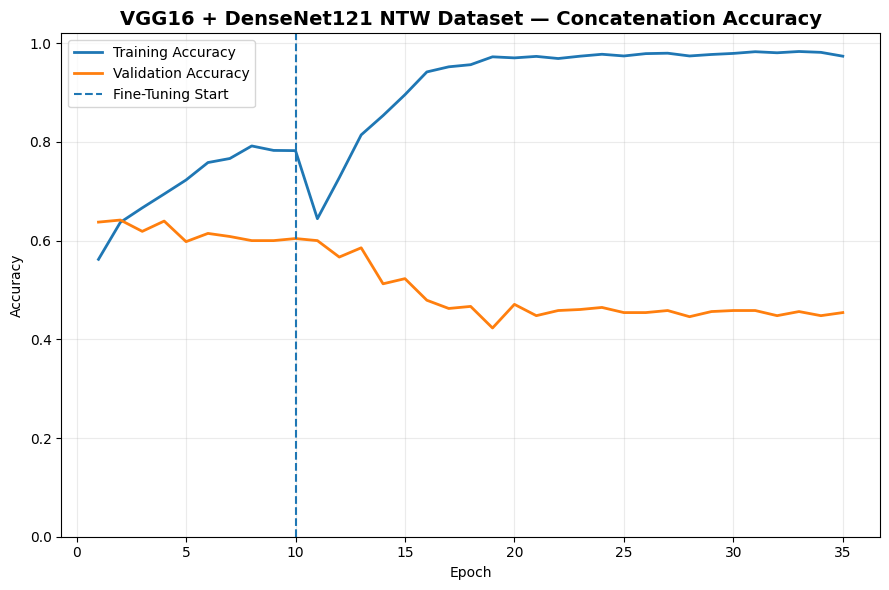

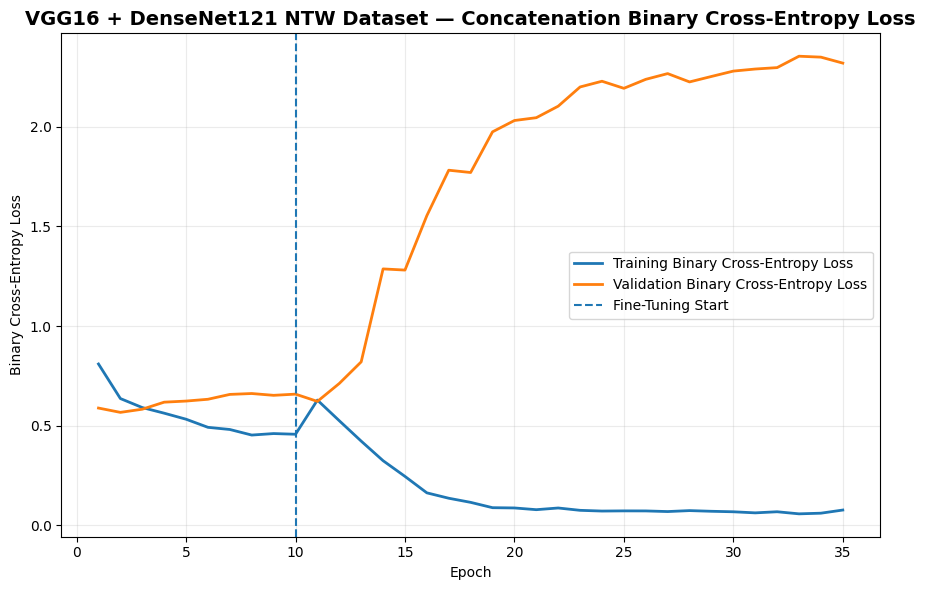

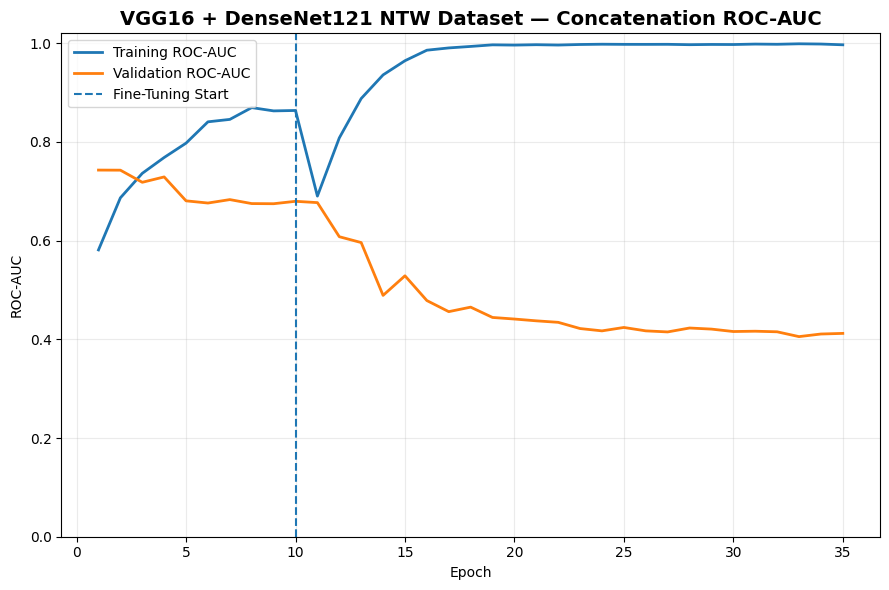

65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step


,Model,Evaluation_Level,Fusion_Type,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,VGG16_DenseNet121_concatenation_NTW,Participant-Level,concatenation,0.538462,0.538462,1.0,0.0,0.7,0.619048,0,6,0,7,13


                 precision    recall  f1-score   support

Healthy Control     0.0000    0.0000    0.0000         6
      Parkinson     0.5385    1.0000    0.7000         7

       accuracy                         0.5385        13
      macro avg     0.2692    0.5000    0.3500        13
   weighted avg     0.2899    0.5385    0.3769        13



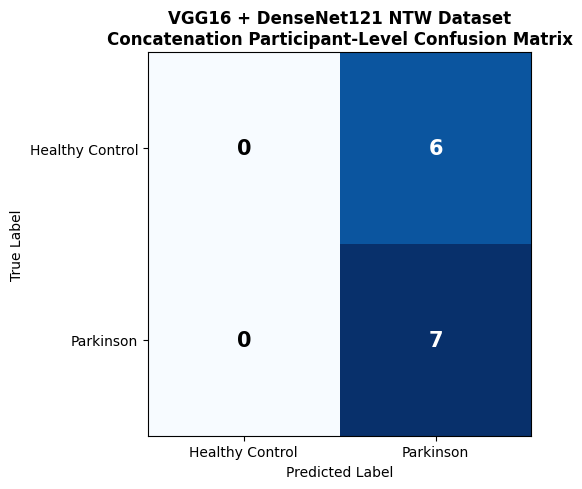

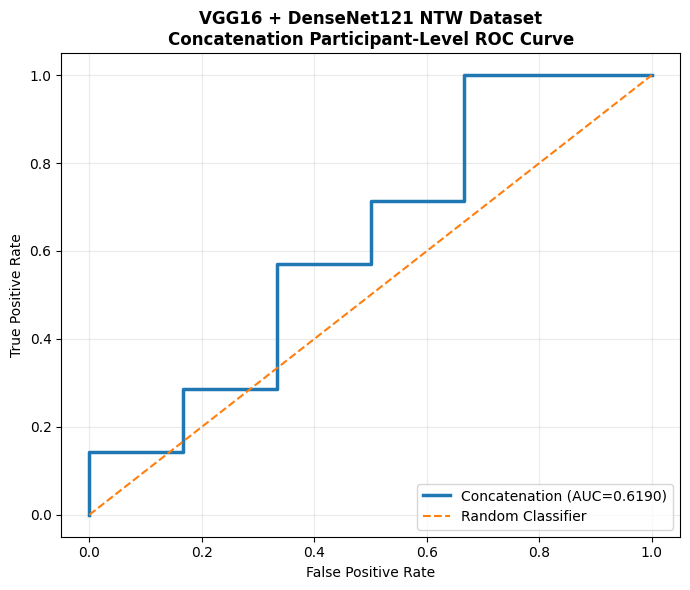

--- Concatenation Fusion Grad-CAM Examples ---
Number of selected examples for Grad-CAM: 3


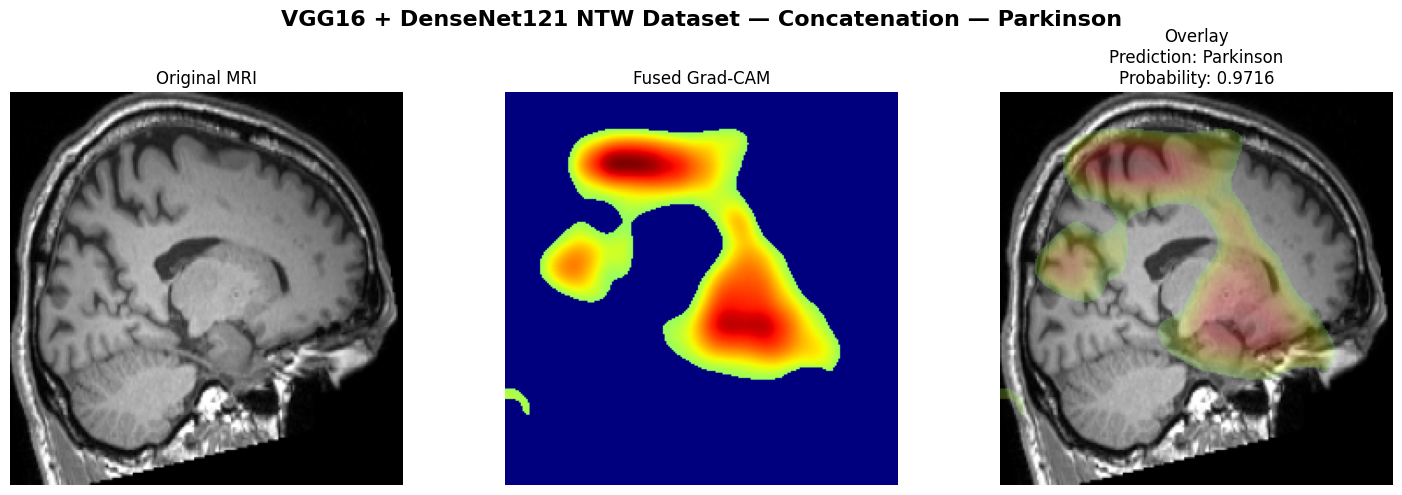

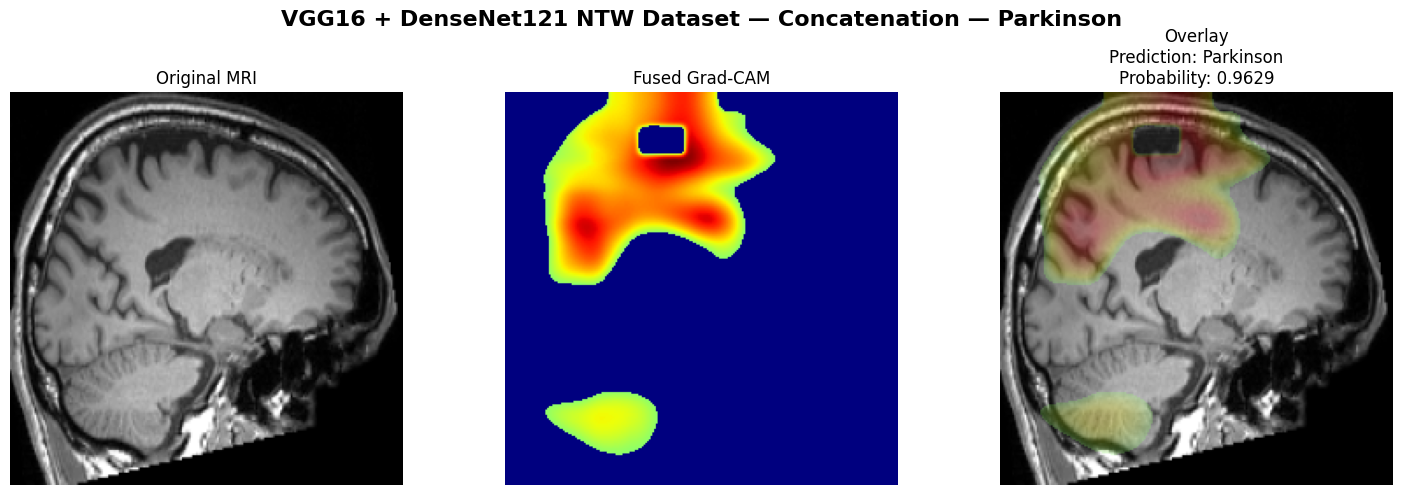

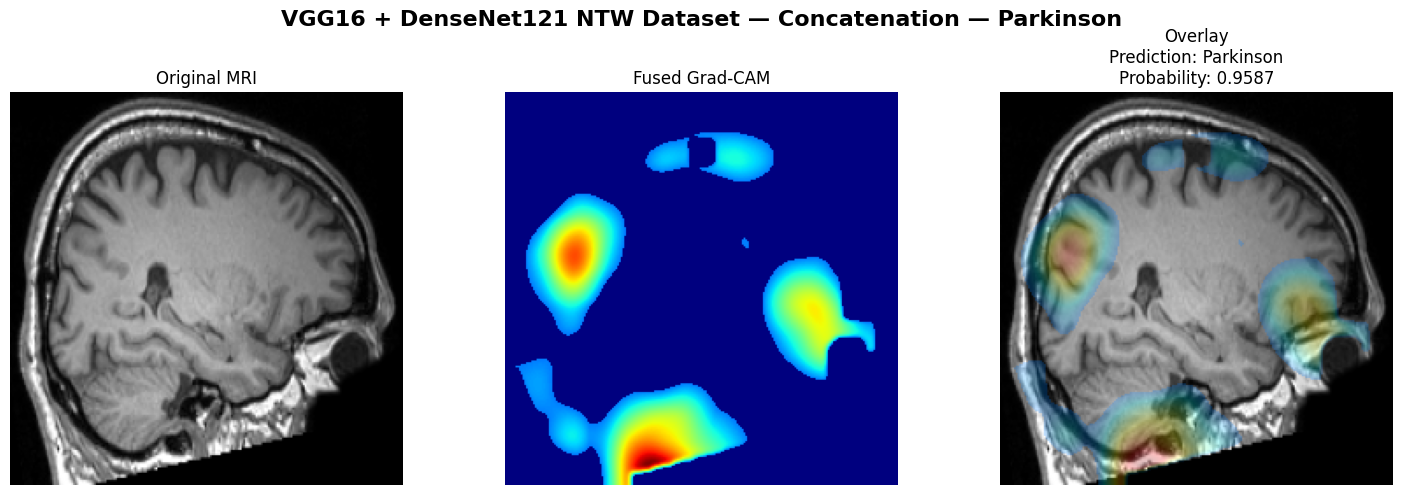


Training VGG16 + DenseNet121 Attention Fusion
Epoch 1/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5432 - auc: 0.5259 - loss: 0.7230
Epoch 1: val_auc improved from None to 0.51336, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/attention/models/VGG16_DenseNet121_attention_NTW_warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/attention/models/VGG16_DenseNet121_attention_NTW_warmup_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 107s 270ms/step - accuracy: 0.5586 - auc: 0.5470 - loss: 0.6996 - val_accuracy: 0.5583 - val_auc: 0.5134 - val_loss: 0.6849 - learning_rate: 1.0000e-04
Epoch 2/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6277 - auc: 0.6629 - loss: 0.6415
Epoch 2: val_au

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_DenseNet121_attention_NTW,22277762,14146178,8131584


Epoch 11/35
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6885 - auc: 0.7641 - loss: 0.5747
Epoch 11: val_auc improved from None to 0.58579, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/attention/models/VGG16_DenseNet121_attention_NTW_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here/attention/models/VGG16_DenseNet121_attention_NTW_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 138s 331ms/step - accuracy: 0.6905 - auc: 0.7587 - loss: 0.5778 - val_accuracy: 0.5458 - val_auc: 0.5858 - val_loss: 0.6995 - learning_rate: 5.0000e-06
Epoch 12/35
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7185 - auc: 0.8047 - loss: 0.5313
Epoch 12: val_auc improved from 0.58579 to 0.60104, saving model to /con

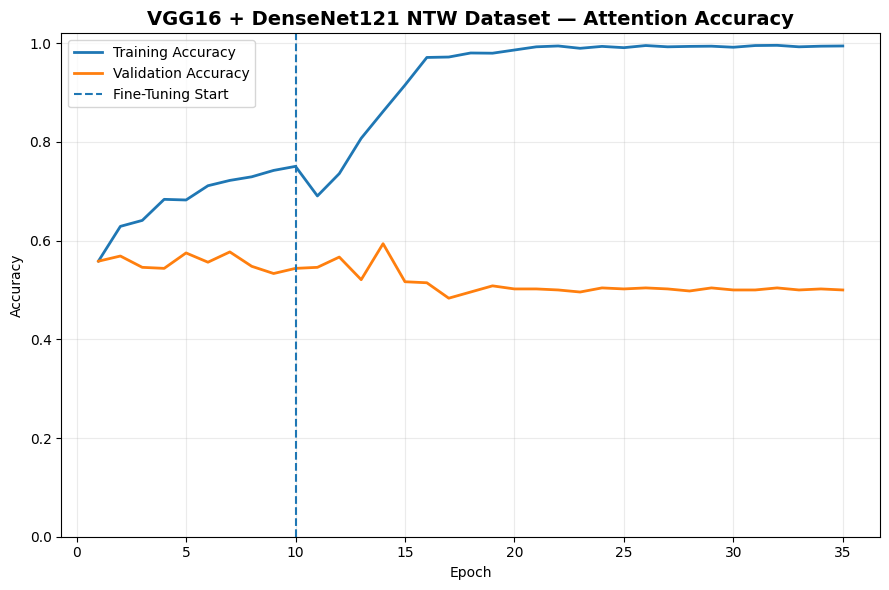

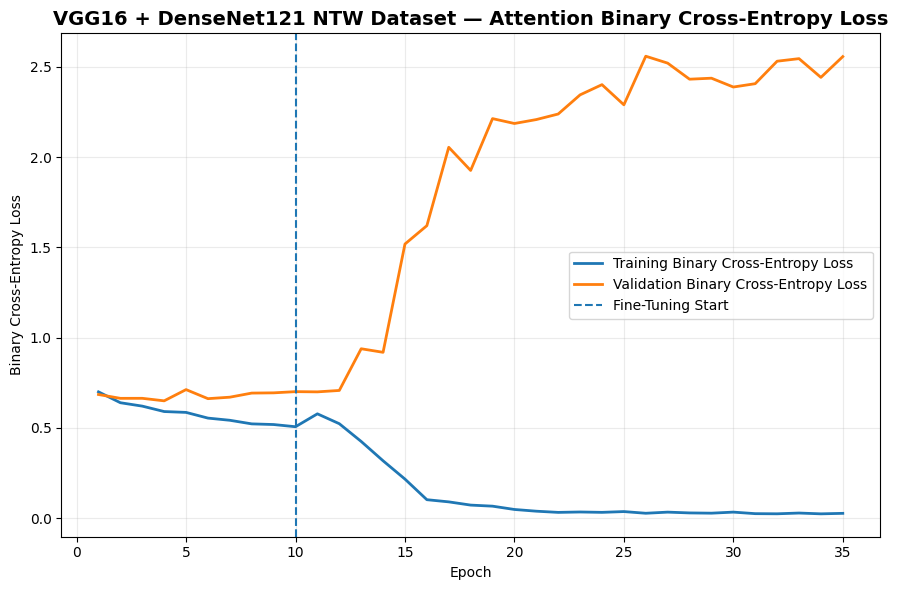

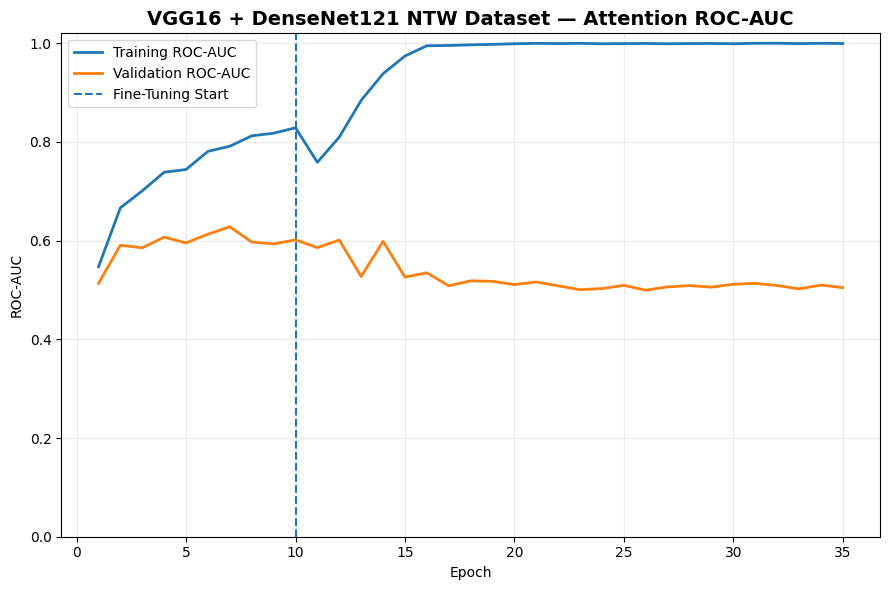

65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step


,Model,Evaluation_Level,Fusion_Type,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,VGG16_DenseNet121_attention_NTW,Participant-Level,attention,0.615385,0.583333,1.0,0.166667,0.736842,0.690476,1,5,0,7,13


                 precision    recall  f1-score   support

Healthy Control     1.0000    0.1667    0.2857         6
      Parkinson     0.5833    1.0000    0.7368         7

       accuracy                         0.6154        13
      macro avg     0.7917    0.5833    0.5113        13
   weighted avg     0.7756    0.6154    0.5286        13



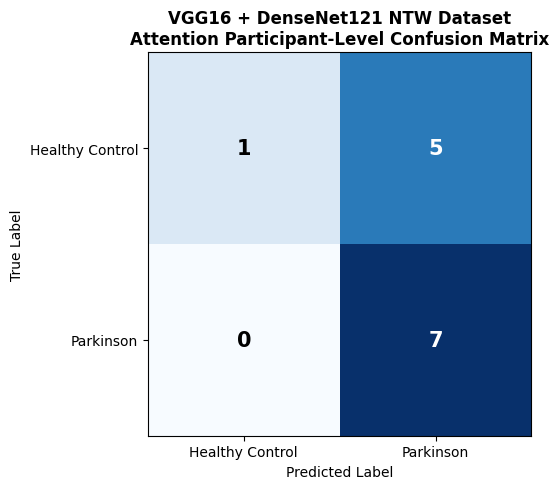

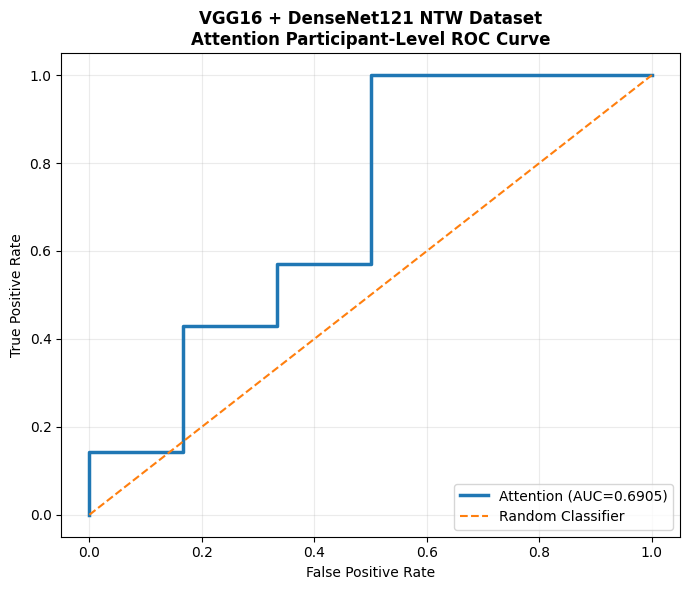

--- Attention Fusion Grad-CAM Examples ---
Number of selected examples for Grad-CAM: 4


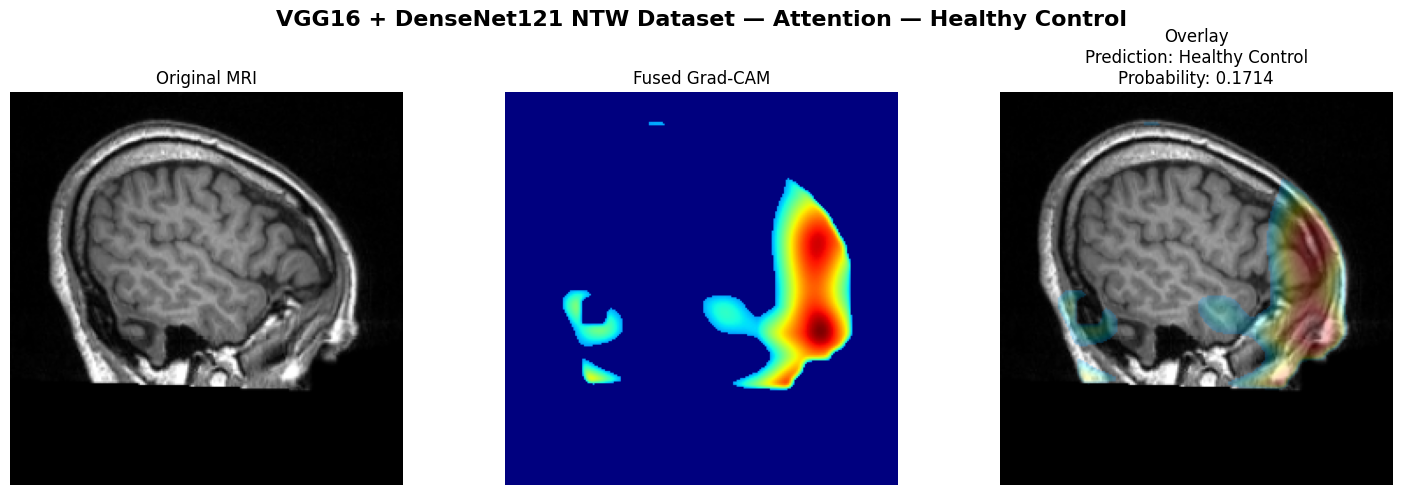

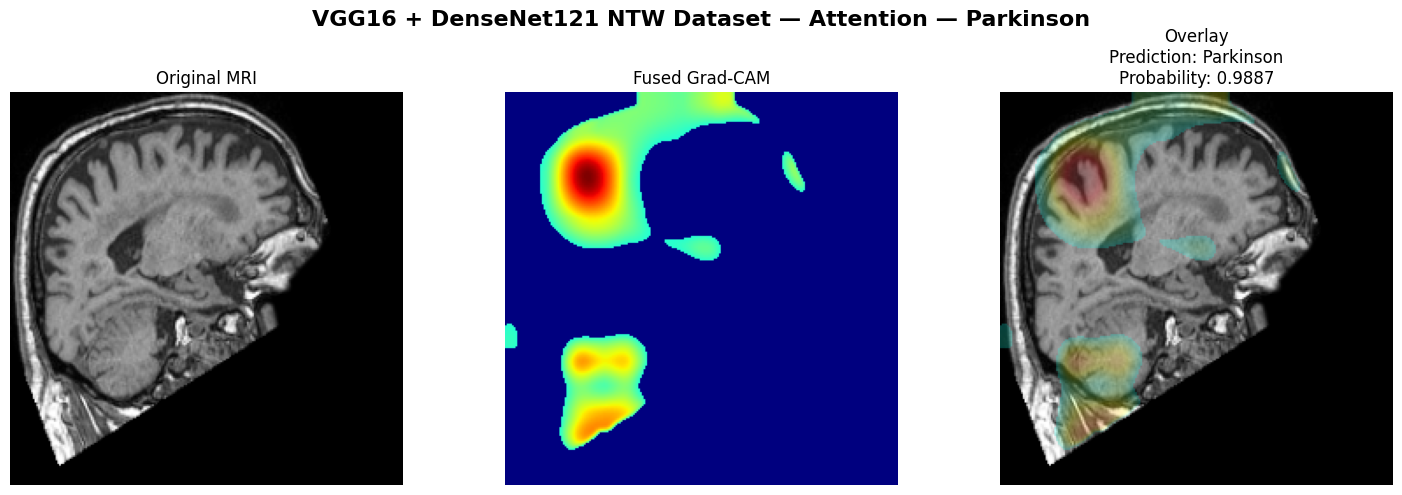

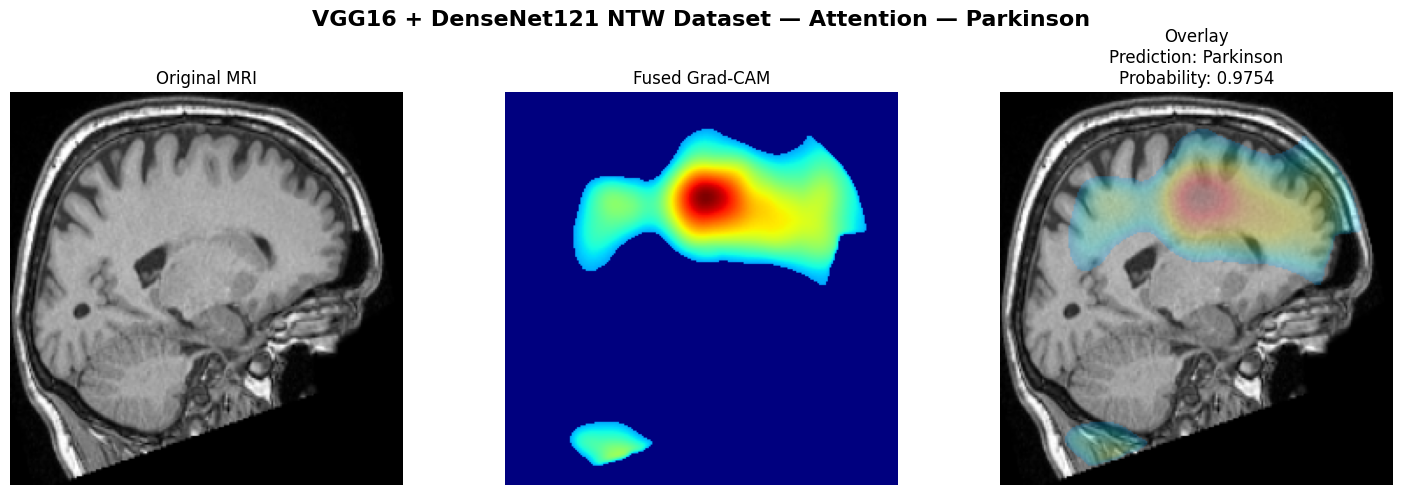

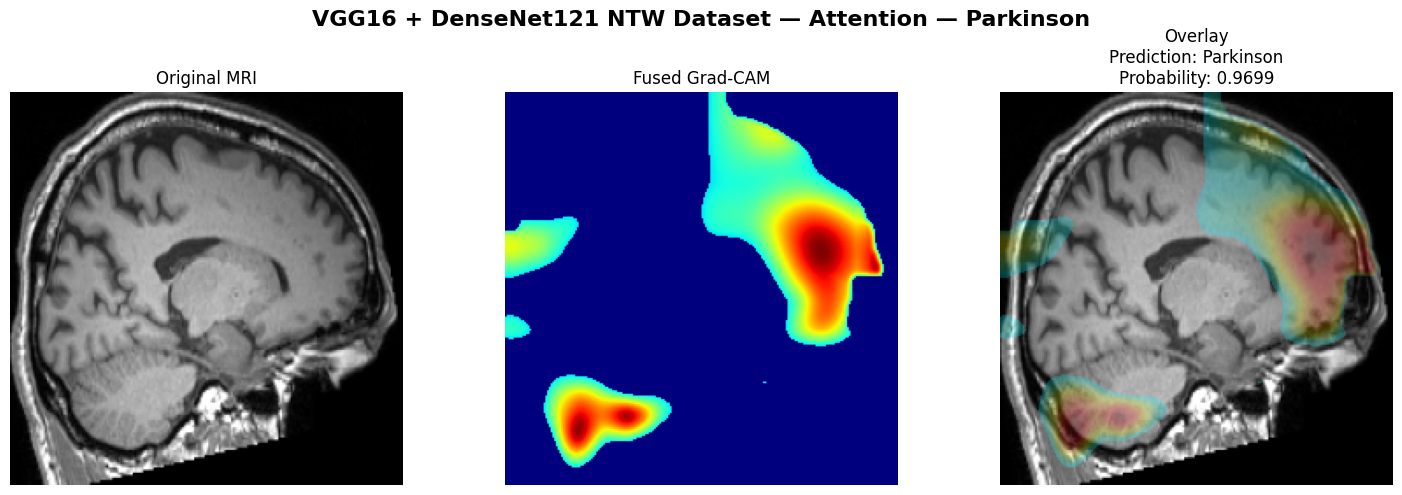

,Model,Evaluation_Level,Fusion_Type,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,VGG16_DenseNet121_concatenation_NTW,Participant-Level,concatenation,0.538462,0.538462,1.0,0.000000,0.700000,0.619048,0,6,0,7,13
1,VGG16_DenseNet121_attention_NTW,Participant-Level,attention,0.615385,0.583333,1.0,0.166667,0.736842,0.690476,1,5,0,7,13


Completed. Results saved in: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/VGG16_Deneset_patient_level_dataset_here


In [13]:
# RUN BOTH FUSION METHODS
all_metrics = []

for fusion_type in FUSION_METHODS:
    print("\n" + "=" * 80)
    print(
        "Training VGG16 + DenseNet121 "
        f"{fusion_type.title()} Fusion"
    )
    print("=" * 80)

    trained_model, run_folders, file_prefix = (
        train_fusion_method(fusion_type)
    )

    method_metrics = evaluate_model(
        trained_model,
        fusion_type,
        run_folders,
        file_prefix,
    )

    all_metrics.append(method_metrics)

    # Free GPU memory before the next model
    del trained_model
    tf.keras.backend.clear_session()

comparison_frame = pd.DataFrame(all_metrics)
display(comparison_frame)

comparison_frame.to_csv(
    Path(SAVE_DIR)
    / "VGG16_DenseNet121_Concatenation_vs_Attention.csv",
    index=False,
)

print("Completed. Results saved in:", SAVE_DIR)